# 01 — EDA y formulación de hipótesis de señal

1. Objetivo y metodología
2. H1 — Momentum vs. Mean Reversion
3. H2 — ¿Cuándo aparece la información?
4. H3 — Volatilidad y régimen direccional
5. H4 — Estado cross-sectional del mercado
6. H5 — Comportamiento relativo al mercado
7. Síntesis de hipótesis y paso a validación

# 01 — EDA y Formulación de Hipótesis de Señal

## 1. Objetivo

La auditoría inicial mostró que el problema consiste en predecir el régimen
direccional de las últimas dos horas de trading a partir de la trayectoria
observada entre las 09:30 y las 14:00.

El objetivo de esta notebook es investigar si dicha trayectoria contiene
estructura estadística potencialmente informativa sobre `reod` y formular
hipótesis concretas que posteriormente puedan evaluarse fuera de muestra.

A diferencia de la auditoría realizada en `00`, esta etapa comienza a estudiar
la relación entre las variables disponibles y el target.

Sin embargo, el propósito todavía no es optimizar un modelo predictivo.

La metodología será:

$$
\text{intuición económica}
\rightarrow
\text{hipótesis}
\rightarrow
\text{evidencia exploratoria}
\rightarrow
\text{hipótesis candidata}
$$

Las relaciones encontradas durante esta notebook se considerarán evidencia
exploratoria y no evidencia fuera de muestra.

Cualquier señal candidata deberá ser evaluada posteriormente mediante un
framework de validación que respete la separación entre días y equities.

## 2. H1 — Momentum vs. Mean Reversion

La primera hipótesis investiga si la dirección acumulada observada antes de
las 14:00 contiene información sobre la dirección posterior.

Existen dos mecanismos potenciales y opuestos.

### Hipótesis de momentum

Si existe persistencia intradía, movimientos positivos durante la ventana
observada deberían estar asociados con una mayor probabilidad de observar
`reod = +1`, mientras que movimientos negativos deberían asociarse con
`reod = -1`.

$$
R^{obs}_{i,d}>0
\Rightarrow
P(Y_{i,d}=+1)\uparrow
$$

### Hipótesis de mean reversion

Alternativamente, si los movimientos intradía tienden a corregirse, retornos
acumulados positivos podrían incrementar la probabilidad de una dirección
posterior negativa, y viceversa.

$$
R^{obs}_{i,d}>0
\Rightarrow
P(Y_{i,d}=-1)\uparrow
$$

El objetivo inicial será determinar cuál de estos dos comportamientos, si
alguno, aparece en los datos.

No sumamos los bps directamente como si fueran el retorno exacto acumulado. 
Tenemos el retorno en puntos base (bps):

$$r_t = 10^4 \left( \frac{P_{t+1}}{P_t} - 1 \right)$$

Entonces podemos reconstruir el retorno compuesto tradicional:

$$R_{0:T} = \prod_{t=0}^{T} \left(1 + \frac{r_t}{10^4}\right) - 1$$

Y volverlo a expresar en puntos base (bps):

$$R_{0:T}^{\text{bps}} = 10^4 \left[ \prod_{t=0}^{T} \left(1 + \frac{r_t}{10^4}\right) - 1 \right]$$

Para movimientos pequeños, $\sum_{t} r_t$ será una aproximación muy buena, pero tenemos 53 observaciones y podemos calcularlo correctamente.


In [8]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
input_train = pd.read_csv('C:../data/input_training.csv ')
input_test = pd.read_csv('C:../data/input_test.csv')
output_train = pd.read_csv('C:../data/output_training_gmEd6Zt.csv')
output_test = pd.read_csv('C:../data/output_test_random.csv')

In [4]:
# para la primera exploración podemos calcular el retorno acumulado solo para trayectorias completas
train = input_train.merge(output_train,on="ID",how="inner",validate="one_to_one")
return_cols = [f"r{i}" for i in range(53)]
analysis = train.copy()
analysis["complete_path"] = (analysis[return_cols].notna().all(axis=1))
complete = analysis.loc[analysis["complete_path"]].copy()
complete["cum_return_bps"] = ((1 + complete[return_cols] / 10_000).prod(axis=1) - 1) * 10_000
print(f"Observaciones totales: {len(analysis):,}")
print(f"Trayectorias completas: {len(complete):,}")
print(f"Porcentaje conservado: "f"{len(complete) / len(analysis):.2%}")

Observaciones totales: 843,299
Trayectorias completas: 600,936
Porcentaje conservado: 71.26%


In [6]:
# dividir el retorno observado en quintiles:
complete["momentum_quintile"] = pd.qcut(complete["cum_return_bps"],q=5,labels=["Q1 - Muy negativo","Q2","Q3","Q4","Q5 - Muy positivo"])
momentum_target = (complete.groupby("momentum_quintile", observed=True)["reod"].value_counts(normalize=True).unstack(fill_value=0))
momentum_target.columns = [f"class_{c}" for c in momentum_target.columns]
momentum_target

,class_-1,class_0,class_1
momentum_quintile,,,
Q1 - Muy negativo,0.365536,0.270601,0.363863
Q2,0.313944,0.380748,0.305308
Q3,0.283383,0.446837,0.269780
Q4,0.309618,0.401216,0.289166
Q5 - Muy positivo,0.363176,0.295115,0.341709


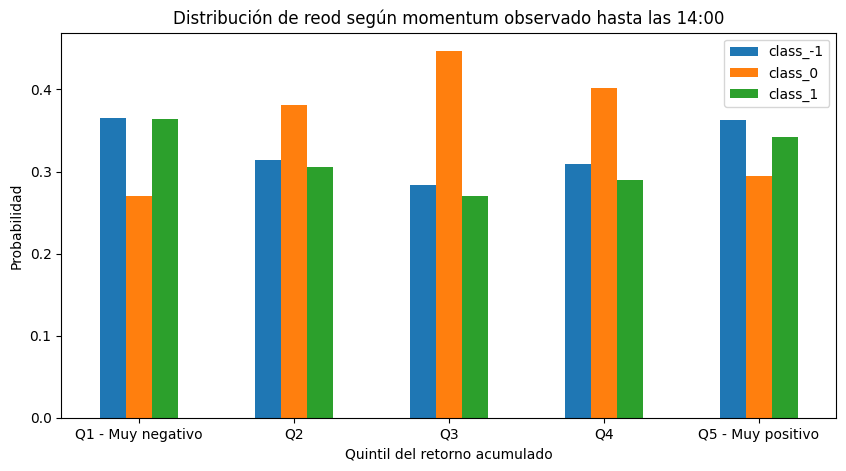

In [12]:
momentum_target.plot(kind="bar",figsize=(10, 5))
#plt.axhline((complete["reod"] == -1).mean(),alpha=0.5)
plt.title("Distribución de reod según momentum observado hasta las 14:00")
plt.xlabel("Quintil del retorno acumulado")
plt.ylabel("Probabilidad")
plt.xticks(rotation=0)
plt.show()

### Resultados de H1 — Momentum vs. Mean Reversion

Para evitar introducir una estrategia de imputación durante esta primera
exploración, el análisis se realizó utilizando únicamente trayectorias completas.

De las 843,299 observaciones disponibles, 600,936 contienen los 53 retornos
intradía observados, equivalentes aproximadamente al 71.26% del conjunto de
training.

Los resultados no muestran evidencia clara de una relación monotónica de
momentum o mean reversion entre el retorno acumulado hasta las 14:00 y la
dirección posterior.

Si existiera momentum simple, esperaríamos que retornos acumulados muy negativos
incrementaran principalmente la probabilidad de `reod = -1` y retornos muy
positivos incrementaran principalmente la probabilidad de `reod = +1`.

Sin embargo, en el quintil más negativo se observa:

$$
P(Y=-1|Q1)\approx36.55\%
$$

y simultáneamente:

$$
P(Y=+1|Q1)\approx36.39\%
$$

De forma similar, en el quintil más positivo aumentan las probabilidades de
ambas clases direccionales.

El patrón más evidente aparece en la probabilidad de la clase neutral.

Para trayectorias intermedias (Q3):

$$
P(Y=0|Q3)\approx44.68\%
$$

mientras que en los extremos:

$$
P(Y=0|Q1)\approx27.06\%
$$

$$
P(Y=0|Q5)\approx29.51\%
$$

Esto sugiere una relación aproximadamente no lineal entre la magnitud del
movimiento previo y el régimen posterior.

En términos exploratorios:

$$
|R^{obs}_{i,d}|\uparrow
\quad\Rightarrow\quad
P(|Y_{i,d}|=1)\uparrow
$$

Por lo tanto, el retorno acumulado parece contener mayor información sobre la
probabilidad de observar posteriormente un régimen direccional fuerte que sobre
el signo específico de dicho movimiento.

### Estado de la hipótesis

La hipótesis inicial de momentum o mean reversion simple no encuentra soporte
claro en esta primera exploración.

Sin embargo, los resultados generan una nueva hipótesis candidata:

> **H1a — Magnitud del movimiento:** movimientos intradía extremos antes de las
> 14:00 podrían estar asociados con una mayor probabilidad de movimientos
> direccionales significativos durante las últimas dos horas, independientemente
> de su dirección.

Esta relación deberá ser evaluada posteriormente fuera de muestra antes de
considerarse una señal predictiva.

## 3. H2 — ¿Cuándo aparece la información?

La primera hipótesis mostró que la magnitud del retorno acumulado hasta las 14:00
presenta una relación no lineal con el régimen direccional posterior.

Sin embargo, utilizar únicamente el retorno acumulado comprime toda la trayectoria
intradía en una sola variable y elimina información sobre cuándo ocurrieron los
movimientos.

Dos activos pueden presentar el mismo retorno acumulado a las 14:00 y, sin embargo,
haber seguido trayectorias muy diferentes.

Por ejemplo, un movimiento ocurrido durante las primeras horas de la sesión podría
tener implicaciones distintas a un movimiento de magnitud similar ocurrido
inmediatamente antes de las 14:00.

Por ello, la segunda hipótesis plantea:

> **H2 — Recencia de la información:** el contenido informativo de los retornos
> intradía sobre `reod` depende del momento de la sesión en el que se producen.

En particular, se investigará si los movimientos más recientes contienen mayor
información sobre el régimen posterior que los movimientos ocurridos varias horas
antes.


### 3.1 Construir ventanas temporales

Tenemos 53 retornos = 265 minutos. Aproximadamente:

1. $r_{0}:r_{17}$ → primeras ~1.5 h.
2. $r_{18}:r_{35} $ → siguientes ~1.5 h.
3. $r_{36}:r_{52} $ → últimas ~1.4 h antes de las 14:00.

Así dividimos la trayectoria aproximadamente en tercios:

Early→Middle→Late

In [14]:
early_cols = [f"r{i}" for i in range(0, 18)]
middle_cols = [f"r{i}" for i in range(18, 36)]
late_cols = [f"r{i}" for i in range(36, 53)]

def compounded_return_bps(df, cols):
    return ((1 + df[cols] / 10_000).prod(axis=1) - 1) * 10_000
complete["return_early"] = compounded_return_bps(complete, early_cols)
complete["return_middle"] = compounded_return_bps(complete, middle_cols)
complete["return_late"] = compounded_return_bps(complete, late_cols)
complete[["return_early", "return_middle", "return_late"]].describe()

,return_early,return_middle,return_late
count,6.009360e+05,600936.000000,600936.000000
mean,5.772071e+03,-0.067963,0.048631
std,2.733390e+06,89.053893,68.740579
min,-9.999895e+03,-2260.286913,-2853.005470
25%,-7.555007e+01,-38.942077,-28.861999
50%,-4.031450e+00,0.008587,0.007387
75%,6.379313e+01,38.968012,29.423033
max,2.046424e+09,7397.147004,4186.724673


###  3.2 Primer test: relación con la dirección futura

Como reod tiene orden direccional: −1, 0, +1

calculamos inicialmente la correlación entre cada retorno de ventana y reod

In [15]:
window_corr = (complete[["return_early", "return_middle", "return_late", "reod"]].corr()["reod"]
    .drop("reod"))
window_corr
# Una correlación de Pearson sólo detecta principalmente relaciones lineales 
# y H1 ya nos enseñó que puede existir una estructura no lineal.
# La usamos únicamente como diagnóstico rápido:
# positiva → posible momentum;
# negativa → posible mean reversion;
# cercana a cero → ausencia de relación lineal, no ausencia de información.

return_early    -3.464237e-07
return_middle    5.680202e-03
return_late     -5.312869e-03
Name: reod, dtype: float64

### 3.3 Lo más importante: neutral vs. direccional por ventana

Aquí conectamos directamente con el hallazgo de H1.
- Creamos:
$ Directional=1(∣reod∣=1) $

In [17]:
complete["directional"] = (complete["reod"].abs() == 1).astype(int)
# para cada ventana construimos quintiles:
window_names = ["return_early","return_middle","return_late"]
directional_results = {}
for col in window_names:
    q_col = f"{col}_quintile"
    complete[q_col] = pd.qcut(complete[col],q=5,labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
    directional_results[col] = (complete.groupby(q_col, observed=True)["directional"].mean())

directional_by_window = pd.DataFrame(directional_results)

directional_by_window

,return_early,return_middle,return_late
Q1,0.719714,0.721154,0.728617
Q2,0.621498,0.609384,0.607953
Q3,0.562116,0.556707,0.554960
Q4,0.601737,0.605648,0.602544
Q5,0.700417,0.712590,0.711408


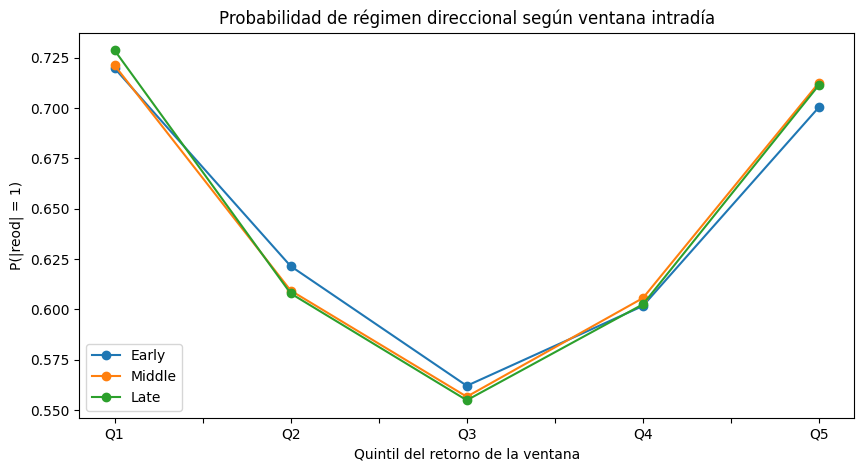

In [18]:
directional_by_window.plot(figsize=(10, 5),marker="o")
plt.title("Probabilidad de régimen direccional según ventana intradía")
plt.xlabel("Quintil del retorno de la ventana")
plt.ylabel("P(|reod| = 1)")
plt.legend(["Early", "Middle", "Late"])
plt.show()

### Resultados de H2 — Localización temporal de la información

La división de la trayectoria observada en tres ventanas —`Early`, `Middle` y
`Late`— permite analizar si la relación identificada previamente depende del
momento de la sesión en el que ocurre el movimiento.

Las tres ventanas presentan un patrón notablemente similar.

En los quintiles centrales, la probabilidad de observar posteriormente un régimen
direccional se sitúa aproximadamente entre 55% y 56%:

$$
P(|Y|=1\mid Q3)\approx 0.55-0.56
$$

En cambio, para los movimientos más extremos de cada ventana, esta probabilidad
aumenta aproximadamente hasta 70%-73%:

$$
P(|Y|=1\mid Q1,Q5)\approx0.70-0.73
$$

Por lo tanto, el patrón no lineal identificado en H1 se reproduce de forma
consistente en diferentes segmentos de la trayectoria intradía:

$$
|R^{window}_{i,d}|\uparrow
\quad\Rightarrow\quad
P(|Y_{i,d}|=1)\uparrow
$$

Este resultado fortalece la hipótesis de que la magnitud de los movimientos
observados contiene información sobre el régimen posterior.

### Evaluación de la hipótesis de recencia

La hipótesis H2 planteaba que los movimientos más cercanos a las 14:00 podrían
contener mayor información que los movimientos ocurridos anteriormente.

Sin embargo, las curvas obtenidas para `Early`, `Middle` y `Late` son muy
similares y no se observa una superioridad clara de la ventana más reciente.

Por lo tanto, esta primera exploración no proporciona evidencia suficiente para
sostener un efecto fuerte de recencia.

La información asociada con la magnitud de los movimientos parece estar presente
a lo largo de diferentes segmentos de la sesión y no exclusivamente en los
intervalos inmediatamente anteriores a las 14:00.

### Relación con la dirección futura

Las correlaciones lineales entre los retornos de las ventanas `Middle` y `Late`
y `reod` son cercanas a cero.

Esto es consistente con los resultados de H1: el signo del retorno pasado parece
contener poca información lineal sobre el signo del movimiento posterior,
mientras que su magnitud presenta una relación considerablemente más clara con
la probabilidad de entrar en un régimen direccional.

En consecuencia, los resultados hasta este punto sugieren distinguir entre dos
problemas:

$$
P(|Y|=1\mid X)
$$

y

$$
P(Y=+1\mid |Y|=1,X)
$$

es decir, predecir primero la existencia de un movimiento direccional y,
separadamente, investigar qué información puede explicar su signo.

### Estado de H2

**H2 — Recencia de la información:** no encuentra soporte claro en esta primera
exploración.

**H1a — Magnitud del movimiento:** recibe evidencia exploratoria adicional, ya
que la relación aparece de manera consistente en las tres ventanas temporales.

In [19]:
complete[early_cols].max().sort_values(ascending=False).head(10)

r0     4.310700e+08
r1     7.516000e+07
r2     4.789000e+07
r3     1.545000e+07
r7     2.733810e+03
r5     2.215870e+03
r10    1.811590e+03
r4     1.554620e+03
r6     1.500000e+03
r13    1.474530e+03
dtype: float64

In [20]:
complete[early_cols].min().sort_values().head(10)

r1    -9973.54
r0    -9967.67
r2    -4823.74
r7    -2066.67
r14   -1713.93
r5    -1416.67
r9    -1390.42
r11   -1379.31
r17   -1354.47
r3    -1337.93
dtype: float64

In [22]:
complete[early_cols].stack().abs().quantile([0.95, 0.99, 0.999, 0.9999, 1.0])

0.9500    7.306000e+01
0.9900    1.468300e+02
0.9990    6.147077e+02
0.9999    2.304272e+03
1.0000    4.310700e+08
dtype: float64

#### Nota sobre valores extremos

Durante la construcción de los retornos acumulados por ventana se identificaron
valores extremos principalmente en los primeros intervalos de la sesión.

La distribución de los retornos individuales presenta aproximadamente:

$$
Q_{0.99}(|r_t|)\approx147\text{ bps}
$$

$$
Q_{0.999}(|r_t|)\approx615\text{ bps}
$$

mientras que un número muy reducido de observaciones alcanza magnitudes varios
órdenes superiores, particularmente en `r0`, `r1`, `r2` y `r3`.

Estos valores explican la media y desviación estándar anómalas observadas en
`return_early`.

Con la información disponible no es posible determinar si corresponden a
movimientos económicos reales, ajustes de precios o características del proceso
de construcción de los datos. Por lo tanto, no serán eliminados ni winsorizados
arbitrariamente durante esta etapa exploratoria.

El análisis principal de H2 se basa en rankings mediante quintiles, lo que reduce
considerablemente la influencia directa de estos valores extremos. Sin embargo,
su tratamiento deberá formar parte del diseño posterior de preprocessing y de
los análisis de robustez.

## 4. H3 — Volatilidad vs. desplazamiento direccional

Los resultados de H1 y H2 muestran una relación consistente entre movimientos
intradía extremos y una mayor probabilidad de observar un régimen direccional
durante las últimas dos horas.

Sin embargo, un retorno acumulado extremo puede aparecer bajo dinámicas
intradía diferentes.

Una trayectoria puede presentar un desplazamiento persistente en una dirección:

$$
+10,+12,+15,+8,+11
$$

mientras que otra puede presentar movimientos grandes pero altamente reversivos:

$$
+40,-35,+45,-42,+38,-40
$$

Ambas contienen actividad significativa, pero representan mecanismos distintos.

Por ello, H3 busca separar dos dimensiones de la trayectoria:

- **desplazamiento:** cuánto se alejó el precio de su punto inicial;
- **volatilidad realizada:** cuánto movimiento ocurrió durante el recorrido.

La hipótesis a evaluar es:

> **H3 — Régimen de volatilidad:** una parte de la relación identificada entre
> movimientos extremos y `reod` podría estar explicada por el nivel de
> volatilidad intradía, y no exclusivamente por el desplazamiento acumulado.

<b> 4.1 Construimos una medida de volatilidad </b>
Para cada trayectoria:

$$RV_{i,d} = \sqrt{ \sum_{t=0}^{52} r_{i,d,t}^2}$$

Trabajando en bps:


In [24]:
complete["realized_vol_bps"] = np.sqrt((complete[return_cols] ** 2).sum(axis=1))
complete["realized_vol_bps"].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99, 0.999])
# ya sabemos que hay outliers extremos.
#  Nos interesan sobre todo mediana y percentiles.
# También conservamos nuestra medida de desplazamiento:

count    6.009360e+05
mean     2.569333e+03
std      7.019229e+05
min      0.000000e+00
50%      1.358547e+02
75%      2.011179e+02
90%      3.022598e+02
95%      4.120214e+02
99%      1.281958e+03
99.9%    2.543899e+03
max      4.310700e+08
Name: realized_vol_bps, dtype: float64

Conceptualmente ahora tenemos dos dimensiones:

$$D = |R_{\text{obs}}|$$

y

$$V = \sum_{t} r_t^2$$


In [ ]:
complete["abs_cum_return_bps"] = (complete["cum_return_bps"].abs())
# 4.2 ¿La volatilidad por sí sola reproduce la U?
# Dividimos realized_vol_bps en quintiles:
complete["vol_quintile"] = pd.qcut(complete["realized_vol_bps"],q=5,labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
vol_directional = (complete.groupby("vol_quintile", observed=True)["directional"].agg(["mean", "count"]))
vol_directional

,mean,count
vol_quintile,,
Q1,0.439254,120188
Q2,0.591137,120187
Q3,0.660088,120187
Q4,0.729205,120187
Q5,0.785800,120187


$$\text{directional} = 1 \iff \text{reod} \in \{-1, +1\}$$

Así que la media es directamente:

$$P(|Y| = 1 \mid \text{Volatility Quintile})$$


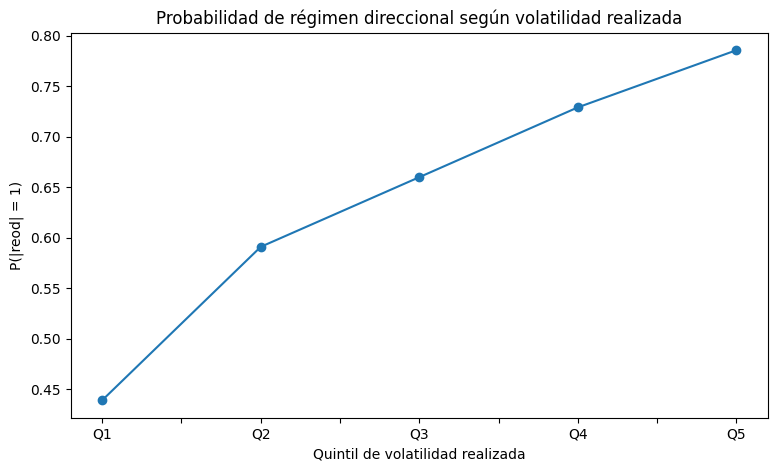

In [28]:
vol_directional["mean"].plot(marker="o",figsize=(9, 5))
plt.title("Probabilidad de régimen direccional según volatilidad realizada")
plt.xlabel("Quintil de volatilidad realizada")
plt.ylabel("P(|reod| = 1)")
plt.show()

### 4.3 El test realmente importante: desplazamiento × volatilidad
Queremos distinguir:

- dado un nivel similar de volatilidad, ¿un gran desplazamiento sigue aportando información?

In [30]:
# Creamos quintiles independientes:
complete["abs_return_quintile"] = pd.qcut(complete["abs_cum_return_bps"],q=5,labels=["D1", "D2", "D3", "D4", "D5"])
complete["vol_quintile"] = pd.qcut(complete["realized_vol_bps"],q=5,labels=["V1", "V2", "V3", "V4", "V5"])
directional_surface = (complete.groupby(["vol_quintile", "abs_return_quintile"],observed=True)["directional"].mean().unstack())
directional_surface

abs_return_quintile,D1,D2,D3,D4,D5
vol_quintile,,,,,
V1,0.397290,0.439250,0.482114,0.528619,0.600000
V2,0.581761,0.582469,0.587234,0.606734,0.646535
V3,0.648947,0.653509,0.653214,0.665571,0.687886
V4,0.718403,0.723970,0.717514,0.729524,0.745574
V5,0.787282,0.790165,0.799371,0.797621,0.778877


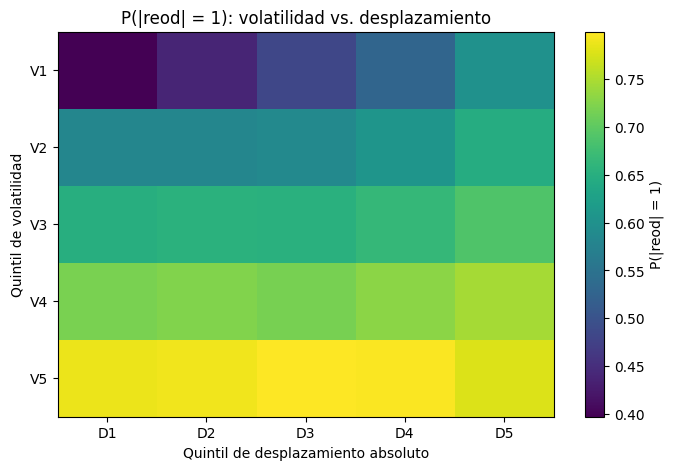

In [31]:
plt.figure(figsize=(8, 5))

plt.imshow(directional_surface.values,aspect="auto")
plt.xticks(range(len(directional_surface.columns)),directional_surface.columns)
plt.yticks(range(len(directional_surface.index)),directional_surface.index)
plt.xlabel("Quintil de desplazamiento absoluto")
plt.ylabel("Quintil de volatilidad")
plt.title("P(|reod| = 1): volatilidad vs. desplazamiento")
plt.colorbar(label="P(|reod| = 1)")
plt.show()

### Resultados de H3 — Volatilidad vs. desplazamiento

La volatilidad realizada observada entre las 09:30 y las 14:00 presenta una
relación monotónica particularmente clara con la probabilidad de observar un
régimen direccional durante las últimas dos horas.

La probabilidad estimada de `|reod| = 1` aumenta progresivamente entre los
quintiles de volatilidad:

| Quintil de volatilidad | P(|reod| = 1) |
|---|---:|
| V1 | 43.93% |
| V2 | 59.11% |
| V3 | 66.01% |
| V4 | 72.92% |
| V5 | 78.58% |

Por lo tanto:

$$
RV_{09:30-14:00}\uparrow
\quad\Rightarrow\quad
P(|Y_{14:00-16:00}|=1)\uparrow
$$

La diferencia entre los quintiles extremos alcanza aproximadamente 35 puntos
porcentuales, constituyendo hasta este punto una de las relaciones exploratorias
más claras identificadas en los datos.

### Volatilidad condicionada por desplazamiento

El análisis conjunto de volatilidad realizada y desplazamiento absoluto permite
separar parcialmente ambos mecanismos.

Manteniendo aproximadamente constante el quintil de desplazamiento, la
probabilidad de un régimen direccional aumenta considerablemente al incrementar
la volatilidad.

Por ejemplo, dentro del menor quintil de desplazamiento (`D1`):

$$
P(|Y|=1|V1,D1)\approx39.7\%
$$

mientras que:

$$
P(|Y|=1|V5,D1)\approx78.7\%
$$

En contraste, dentro de los regímenes de volatilidad elevada, modificar el
quintil de desplazamiento produce diferencias considerablemente menores.

En `V5`, por ejemplo, las probabilidades permanecen aproximadamente entre 78% y
80% para prácticamente todos los quintiles de desplazamiento.

Esto sugiere que la volatilidad realizada explica una parte considerable de la
relación encontrada previamente entre movimientos acumulados extremos y
`reod`.

### Reinterpretación de H1

Los resultados de H1 mostraban que grandes desplazamientos absolutos estaban
asociados con una mayor probabilidad de observar posteriormente un régimen
direccional.

H3 sugiere que esta relación podría estar capturando, en buena medida, un régimen
subyacente de volatilidad.

En términos exploratorios, la evidencia encontrada hasta ahora es más consistente
con:

$$
\text{High Intraday Volatility}
\rightarrow
\text{Higher Probability of Directional EOD Regime}
$$

que con una relación simple de momentum o mean reversion.

El desplazamiento todavía parece aportar información adicional en algunos
regímenes de baja volatilidad, por lo que ambos componentes no deben considerarse
completamente equivalentes.

### Estado de H3

**H3 — Régimen de volatilidad:** recibe evidencia exploratoria fuerte.

La volatilidad realizada se establece como una de las principales señales
candidatas para las etapas posteriores de validación.

Sin embargo, esta relación ha sido identificada dentro del conjunto de training
y todavía deberá demostrar estabilidad entre días y capacidad de generalización
fuera de muestra antes de considerarse una señal predictiva robusta.

## 5. H4 — Estado cross-sectional del mercado

Hasta este punto, las hipótesis H1-H3 han estudiado cada trayectoria de forma
individual:

$$
X_{i,d} \rightarrow Y_{i,d}
$$

Sin embargo, la auditoría inicial mostró que la distribución de `reod` presenta
una heterogeneidad considerable entre días. Existen jornadas en las que una gran
proporción de las equities termina en el mismo régimen direccional.

Esto sugiere que parte del comportamiento futuro de una equity podría depender
no solamente de su propia trayectoria, sino también del estado agregado del
mercado durante ese día.

La cuarta hipótesis plantea:

> **H4 — Estado cross-sectional:** las condiciones agregadas observadas entre
> las 09:30 y las 14:00 contienen información sobre el régimen de las últimas
> dos horas que no está representada únicamente por la trayectoria individual.

Para caracterizar este estado se utilizarán exclusivamente variables construidas
con información disponible hasta las 14:00, preservando la frontera temporal
establecida durante la auditoría.

### 5.1 Construimos el estado de mercado por día

Aquí haría sólo tres variables, cada una con una interpretación distinta:

$ MarketReturn_d $ : dirección agregada,

$ MarketVol_d $ : actividad/volatilidad agregada,

$ Breadth_d $ : qué proporción de equities viene subiendo.

Tenemos un problema: ´complete´ excluye equities con NaN y eso podría cambiar la composición cross-sectional de cada día. Para esta primera exploración asi lo hacemos, pero debemos documentarlo.

In [ ]:
# construimos el estado de mercado por dia 
complete["positive_path"] = (complete["cum_return_bps"] > 0).astype(int)
market_state = (complete.groupby("day").agg(market_return=("cum_return_bps", "median"),market_vol=("realized_vol_bps", "median"),
market_breadth=("positive_path", "mean"),n_equities=("equity", "nunique")).reset_index())
market_state.describe()

,day,market_return,market_vol,market_breadth,n_equities
count,497.000000,497.000000,497.000000,497.000000,497.000000
mean,250.617706,-4.456064,136.761654,0.486510,1209.126761
std,145.394509,51.139737,26.087952,0.147838,59.853029
min,0.000000,-207.829064,98.633086,0.093698,952.000000
25%,125.000000,-29.322586,118.754343,0.385691,1189.000000
50%,251.000000,-2.004639,130.037013,0.491653,1198.000000
75%,376.000000,22.443656,146.671636,0.591253,1210.000000
max,502.000000,189.990118,279.122563,0.887510,1485.000000


### ¿Por qué mediana y no media?

Por los outliers que encontramos:

$$431,070,000 \text{ bps}$$

No quiero que una equity destruya nuestro proxy de estado del mercado.

Entonces:

$$\text{MarketReturn}_d = \operatorname{Median}_i (R_{i,d})$$

$$\text{MarketVol}_d = \operatorname{Median}_i (\text{RV}_{i,d})$$

$$\text{Breadth}_d = \frac{1}{N_d} \sum_{i} \mathbb{1}(R_{i,d} > 0)$$


### 5.2 ¿El estado del mercado está relacionado con el régimen futuro del día?

Necesitamos una variable que describa lo que posteriormente ocurrió en el día.

In [39]:
# el mercado esta relacionado con el refimen futuro del dia? 
daily_outcome = (complete.groupby("day").agg(future_negative=("reod", lambda x: (x == -1).mean()),
                      future_neutral=("reod", lambda x: (x == 0).mean()),future_positive=("reod", lambda x: (x == 1).mean()),
                      future_directional=("directional", "mean")).reset_index())

# unimos 
daily_analysis = market_state.merge(daily_outcome,on="day",validate="one_to_one")
daily_analysis

,day,market_return,market_vol,market_breadth,n_equities,future_negative,future_neutral,future_positive,future_directional
0,0,62.042702,132.678674,0.741138,1213,0.800495,0.153339,0.046167,0.846661
1,1,-98.747401,192.624199,0.220353,1189,0.747687,0.171573,0.080740,0.828427
2,2,21.231764,134.025617,0.578505,1191,0.330814,0.376994,0.292191,0.623006
3,3,13.920478,127.490317,0.562290,1188,0.158249,0.372896,0.468855,0.627104
4,4,-0.069612,131.850718,0.500000,1202,0.876872,0.079867,0.043261,0.920133
...,...,...,...,...,...,...,...,...,...
492,498,-50.553510,114.834697,0.299411,1189,0.254836,0.377628,0.367536,0.622372
493,499,16.761852,113.467832,0.566416,1197,0.212197,0.449457,0.338346,0.550543
494,500,-104.459229,187.104117,0.243579,1207,0.111848,0.205468,0.682684,0.794532
495,501,15.012235,134.406699,0.559194,1191,0.554996,0.351805,0.093199,0.648195


`future_*` se utiliza aquí sólo como variable objetivo para estudiar la hipótesis.

La relación permitida es:

$$\underbrace{\text{MarketState}_{t \le \text{14:00}}}_{\text{feature}} \longrightarrow \underbrace{\text{FutureOutcome}_{\text{14:00} - \text{16:00}}}_{\text{target}}$$


### 5.3 Primero: volatilidad del mercado

H3 encontró una señal individual muy fuerte.

Ahora preguntamos si también existe a nivel agregado:

$$\text{MarketVol}_d \uparrow \implies P(|Y| = 1 \mid \text{day}) \uparrow ?$$


In [34]:
# Creamos quintiles de días, no de equities:
daily_analysis["market_vol_quintile"] = pd.qcut(daily_analysis["market_vol"],q=5,labels=["V1", "V2", "V3", "V4", "V5"])
market_vol_result = (daily_analysis.groupby("market_vol_quintile", observed=True)["future_directional"].agg(["mean", "std", "count"]))
market_vol_result

,mean,std,count
market_vol_quintile,,,
V1,0.576546,0.076457,100
V2,0.593453,0.063801,99
V3,0.640128,0.096811,99
V4,0.660081,0.091542,99
V5,0.735976,0.120608,100


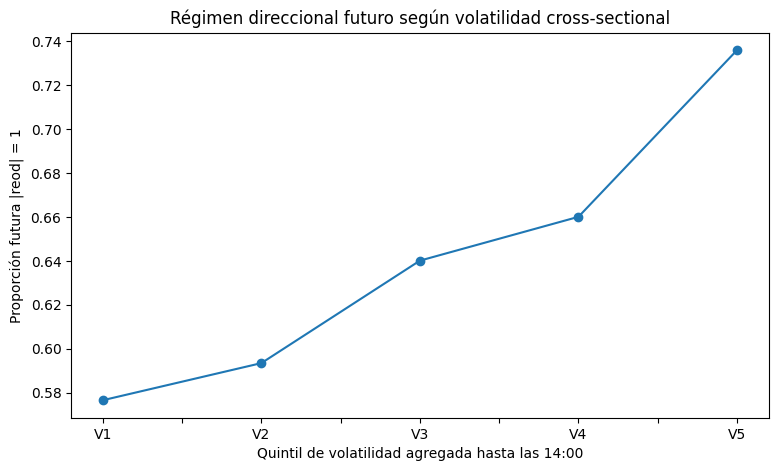

In [35]:
market_vol_result["mean"].plot(marker="o",figsize=(9, 5))
plt.title("Régimen direccional futuro según volatilidad cross-sectional")
plt.xlabel("Quintil de volatilidad agregada hasta las 14:00")
plt.ylabel("Proporción futura |reod| = 1")
plt.show()

### 5.4 Dirección del mercado: return + breadth

Ahora viene una pregunta distinta.

No queremos saber simplemente si habrá movimiento. Queremos empezar a investigar el signo.

Si el mercado hasta las 14:00 viene positivo:

$$\text{MarketReturn}_d > 0$$

y:

$$\text{Breadth}_d > 0.5$$

¿Las últimas dos horas también presentan mayor proporción de $+1$?


In [ ]:
# direccion de mercado : return + breadth 
daily_analysis["market_return_quintile"] = pd.qcut(daily_analysis["market_return"],q=5,labels=["R1", "R2", "R3", "R4", "R5"])
market_direction_result = (daily_analysis.groupby("market_return_quintile", observed=True).agg(future_negative=("future_negative", "mean"),
future_neutral=("future_neutral", "mean"),future_positive=("future_positive", "mean")))
market_direction_result

,future_negative,future_neutral,future_positive
market_return_quintile,,,
R1,0.355289,0.312022,0.332689
R2,0.332647,0.373401,0.293952
R3,0.333824,0.382888,0.283288
R4,0.281589,0.392066,0.326345
R5,0.332239,0.333861,0.333900


In [ ]:
# matriz de correlacion 
daily_analysis[
    ["market_return",
     "market_vol",
     "market_breadth",
     "future_negative",
     "future_neutral",
     "future_positive",
     "future_directional"]].corr().round(3)

,market_return,market_vol,market_breadth,future_negative,future_neutral,future_positive,future_directional
market_return,1.000,-0.080,0.971,-0.072,0.103,0.019,-0.103
market_vol,-0.080,1.000,-0.068,0.095,-0.557,0.225,0.557
market_breadth,0.971,-0.068,1.000,-0.066,0.087,0.021,-0.087
future_negative,-0.072,0.095,-0.066,1.000,-0.440,-0.846,0.440
future_neutral,0.103,-0.557,0.087,-0.440,1.000,-0.106,-1.000
future_positive,0.019,0.225,0.021,-0.846,-0.106,1.000,0.106
future_directional,-0.103,0.557,-0.087,0.440,-1.000,0.106,1.000


### Resultados de H4 — Estado cross-sectional del mercado

El análisis cross-sectional se realizó sobre 497 días, utilizando medidas robustas
construidas a partir de las equities con trayectoria completa disponibles en cada
jornada.

Los resultados muestran que la volatilidad agregada del mercado antes de las
14:00 presenta una relación clara con la proporción de equities que posteriormente
terminan en un régimen direccional.

La probabilidad media de observar `|reod| = 1` aumenta progresivamente entre los
quintiles de volatilidad agregada:

| Quintil | P(|reod| = 1) |
|---|---:|
| V1 | 57.65% |
| V2 | 59.35% |
| V3 | 64.01% |
| V4 | 66.01% |
| V5 | 73.60% |

Además:

$$
Corr(MarketVol_d,FutureDirectional_d)\approx0.557
$$

Por lo tanto, la evidencia encontrada en H3 a nivel individual también aparece
a nivel agregado.

Esto sugiere que el régimen futuro puede depender de al menos dos componentes:

$$
\text{Individual Volatility State}
+
\text{Common Market Volatility State}
$$

### Información sobre el signo

En contraste, las variables asociadas con la dirección agregada del mercado
presentan poca relación con el signo futuro.

Para los días pertenecientes al quintil más positivo del retorno agregado:

$$
P(Y=-1)\approx33.2\%
$$

$$
P(Y=+1)\approx33.4\%
$$

y las correlaciones entre `market_return`, `market_breadth` y las proporciones
futuras positivas o negativas son cercanas a cero.

Por lo tanto, no se encuentra evidencia clara de momentum direccional agregado
entre el comportamiento observado hasta las 14:00 y el signo de los movimientos
durante las últimas dos horas.

### Redundancia entre variables agregadas

`market_return` y `market_breadth` presentan una correlación aproximada de:

$$
Corr(MarketReturn,MarketBreadth)\approx0.971
$$

lo que indica que ambas variables representan prácticamente la misma dimensión
direccional del estado cross-sectional.

En contraste, `market_vol` presenta correlaciones reducidas con ambas variables,
por lo que captura una dimensión diferente del estado del mercado.

### Estado de H4

**H4 — Estado cross-sectional:** recibe soporte parcial.

Existe evidencia clara de que el régimen de volatilidad agregado contiene
información sobre la probabilidad de movimientos direccionales posteriores.

Sin embargo, no se encuentra evidencia comparable de que la dirección agregada
del mercado permita anticipar de forma sencilla el signo futuro de `reod`.

En conjunto con H3, estos resultados sugieren que la volatilidad podría contener
información tanto idiosincrática como común al mercado.

## 6. H5 — Forma de la trayectoria y dirección futura

Las hipótesis anteriores muestran que la volatilidad intradía contiene información
considerable sobre la probabilidad de observar un movimiento significativo durante
las últimas dos horas.

Sin embargo, predecir la dirección específica del movimiento continúa siendo
considerablemente más difícil.

Ni el retorno acumulado individual ni la dirección agregada del mercado mostraron
una relación clara de momentum o mean reversion con `reod`.

Esto sugiere que el signo futuro podría depender de características de la
trayectoria que no pueden representarse únicamente mediante el retorno acumulado
o la volatilidad.

Dos trayectorias pueden presentar retornos y volatilidades similares y, sin
embargo, diferir sustancialmente en su estructura temporal.

Por ello, la quinta hipótesis plantea:

> **H5 — Forma de la trayectoria:** características relacionadas con la
> persistencia, reversión y evolución temporal del movimiento intradía podrían
> contener información adicional sobre la dirección de `reod`.

Esta hipótesis se analizará mediante un conjunto reducido de estadísticas
interpretables antes de recurrir a modelos secuenciales más complejos.

#### 6.1 Persistencia de signo
¿Una trayectoria compuesta consistentemente por retornos positivos/negativos contiene más información que simplemente su retorno acumulado?

Construimos la proporción de intervalos positivos y negativos.

In [40]:
complete["positive_share"] = (complete[return_cols] > 0).mean(axis=1)
complete["negative_share"] = (complete[return_cols] < 0).mean(axis=1)

In [ ]:
# persistencia del signo
complete[["positive_share", "negative_share"]].describe()

,positive_share,negative_share
count,600936.000000,600936.000000
mean,0.406715,0.409298
std,0.106921,0.107171
min,0.000000,0.000000
25%,0.339623,0.339623
50%,0.415094,0.415094
75%,0.490566,0.490566
max,0.773585,0.792453


In [43]:
# dividimos positive_share en quintiles:
complete["positive_share_quintile"] = pd.qcut(complete["positive_share"],q=5,labels=False,duplicates="drop")
# Uso labels=False y duplicates="drop" porque esta variable es discreta y podríamos no tener cinco cortes únicos exactos
persistence_result = (complete.groupby("positive_share_quintile", observed=True).agg(
    future_negative=("reod", lambda x: (x == -1).mean()),
    future_neutral=("reod", lambda x: (x == 0).mean()),
    future_positive=("reod", lambda x: (x == 1).mean()),
    count=("reod", "size")))
persistence_result

,future_negative,future_neutral,future_positive,count
positive_share_quintile,,,,
0,0.325837,0.360537,0.313626,132910
1,0.333314,0.349270,0.317416,139451
2,0.328020,0.357069,0.314912,89641
3,0.324613,0.364702,0.310686,125371
4,0.323133,0.363869,0.312998,113563


### 6.2 Reversals

Ahora estudiamos algo diferente: qué tan errática fue la trayectoria.

Un reversal ocurre cuando cambia el signo entre dos retornos consecutivos:

$$\operatorname{sign}(r_t) \neq \operatorname{sign}(r_{t-1})$$


In [45]:
def count_reversals(row):
    signs = np.sign(row)
    signs = signs[signs != 0]
    if len(signs) < 2:
        return 0
    return np.sum(signs[1:] != signs[:-1])


complete["reversal_count"] = (complete[return_cols].apply(lambda row: count_reversals(row.to_numpy()),axis=1))
complete["reversal_count"].describe()

count    600936.000000
mean         21.437260
std           5.595351
min           0.000000
25%          18.000000
50%          22.000000
75%          25.000000
max          41.000000
Name: reversal_count, dtype: float64

In [46]:
# quantiles 
complete["reversal_quintile"] = pd.qcut(complete["reversal_count"],q=5,labels=False,duplicates="drop")

reversal_result = (complete.groupby("reversal_quintile", observed=True).agg(
    future_negative=("reod", lambda x: (x == -1).mean()),
    future_neutral=("reod", lambda x: (x == 0).mean()),
    future_positive=("reod", lambda x: (x == 1).mean()),
    future_directional=("directional", "mean"),
    count=("reod", "size")))
reversal_result

,future_negative,future_neutral,future_positive,future_directional,count
reversal_quintile,,,,,
0,0.324292,0.364852,0.310855,0.635148,132914
1,0.334293,0.348984,0.316723,0.651016,142064
2,0.328868,0.357612,0.313521,0.642388,92332
3,0.329168,0.359687,0.311145,0.640313,127005
4,0.317198,0.364891,0.317911,0.635109,106621


### 6.3  cambio Early → Late

H2 nos dijo que early, middle y late por separado tienen estructuras similares.

Pero todavía no preguntamos cómo evoluciona la trayectoria entre ventanas.

Definimos:

$$\Delta R = R_{\text{late}} - R_{\text{early}}$$


In [47]:
complete["early_late_change"] = (complete["return_late"] - complete["return_early"])
#por los outliers de return_early, prefiero evitar usar directamente la magnitud bruta.

In [ ]:
# algo más robusto e interpretable: el signo Early/Late.
complete["early_sign"] = np.sign(complete["return_early"])
complete["late_sign"] = np.sign(complete["return_late"])
# construimos cuatro estados principales:
def path_transition(row):
    early = row["early_sign"]
    late = row["late_sign"]
    if early < 0 and late < 0:
        return "Neg → Neg"
    elif early < 0 and late > 0:
        return "Neg → Pos"
    elif early > 0 and late < 0:
        return "Pos → Neg"
    elif early > 0 and late > 0:
        return "Pos → Pos"
    else:
        return "Con cero"
complete["path_transition"] = complete.apply(path_transition,axis=1)

In [49]:
#vemos tamaños
complete["path_transition"].value_counts(normalize=True)

path_transition
Neg → Neg    0.259029
Neg → Pos    0.258660
Pos → Pos    0.245196
Pos → Neg    0.235571
Con cero     0.001544
Name: proportion, dtype: float64

In [50]:
transition_result = (complete.groupby("path_transition").agg(
        future_negative=("reod", lambda x: (x == -1).mean()),
        future_neutral=("reod", lambda x: (x == 0).mean()),
        future_positive=("reod", lambda x: (x == 1).mean()),
        count=("reod", "size")
    ))
transition_result

,future_negative,future_neutral,future_positive,count
path_transition,,,,
Con cero,0.284483,0.455819,0.259698,928
Neg → Neg,0.328569,0.345876,0.325556,155660
Neg → Pos,0.323505,0.360382,0.316113,155438
Pos → Neg,0.328299,0.361895,0.309806,141563
Pos → Pos,0.328585,0.367622,0.303793,147347


### Un último diagnóstico conjunto

In [51]:
shape_corr = complete[["positive_share","negative_share","reversal_count",
                       "cum_return_bps","realized_vol_bps","reod"]].corr()
shape_corr["reod"].sort_values()

realized_vol_bps   -7.882603e-05
cum_return_bps     -5.474569e-07
positive_share      4.996026e-04
reversal_count      4.504483e-03
negative_share      7.196041e-03
reod                1.000000e+00
Name: reod, dtype: float64

### Resultados de H5 — Forma de la trayectoria

Las estadísticas simples utilizadas para representar la forma de la trayectoria
no muestran evidencia relevante de capacidad predictiva sobre el signo futuro.

La proporción de retornos intradía positivos (`positive_share`) produce
distribuciones de `reod` prácticamente estables entre sus diferentes quintiles.
En particular, una mayor persistencia de retornos positivos no incrementa de
forma apreciable la probabilidad de observar `reod = +1`.

El número de cambios de signo (`reversal_count`) tampoco presenta una relación
monotónica con el régimen futuro. La probabilidad de observar un movimiento
direccional permanece aproximadamente entre 63% y 65% a través de todos sus
quintiles.

Finalmente, la clasificación de las trayectorias según la transición entre las
ventanas early y late tampoco proporciona evidencia clara de momentum o
mean reversion.

Por ejemplo, incluso para trayectorias positivas tanto al inicio como al final
del periodo observado:

$$
P(reod=+1 \mid Pos\rightarrow Pos)\approx30.4\%
$$

mientras que:

$$
P(reod=-1 \mid Pos\rightarrow Pos)\approx32.9\%
$$

Por lo tanto, la persistencia direccional observada antes de las 14:00 no se
traduce directamente en persistencia del signo durante las últimas dos horas.

Las correlaciones lineales con `reod` son igualmente cercanas a cero para
`positive_share`, `negative_share`, `reversal_count` y `cum_return_bps`.

Debe señalarse que una correlación cercana a cero con `reod` no implica
necesariamente ausencia de información predictiva. En particular,
`realized_vol_bps` presenta correlación aproximadamente nula con el signo de
`reod`, aunque H3 mostró una relación considerable con su magnitud:

$$
RealizedVol \uparrow
\Rightarrow
P(|reod|=1)\uparrow
$$

Esto confirma la necesidad de distinguir entre dos problemas diferentes:
predecir la existencia de un movimiento direccional y predecir posteriormente
su signo.

### Estado de H5

**H5 — Forma de la trayectoria:** no recibe soporte mediante las estadísticas
simples analizadas.

La persistencia del signo, el número de reversals y las transiciones early-late
no proporcionan una separación relevante entre los regímenes futuros.

Esto no permite concluir que la secuencia intradía completa carezca de
información temporal. Únicamente indica que dicha información, si existe, no
queda representada adecuadamente mediante estas estadísticas resumidas.

# 7. Research Findings & Modeling Implications

El análisis exploratorio permitió estudiar qué componentes de la trayectoria
intradía observada hasta las 14:00 contienen información sobre el régimen
direccional de las últimas dos horas.

El principal resultado es que la información predictiva encontrada no parece
estar distribuida de forma homogénea entre la **magnitud** y el **signo** del
movimiento futuro.

## 7.1 Principales hallazgos

### H1 — Retorno acumulado

El retorno acumulado hasta las 14:00 no presenta una relación monotónica simple
con el signo futuro.

Sin embargo, las trayectorias con desplazamientos extremos presentan una mayor
probabilidad de terminar en un régimen direccional que aquellas con movimientos
intermedios.

Esto sugiere una relación no lineal entre desplazamiento y régimen futuro.

---

### H2 — Localización temporal del movimiento

Separar la trayectoria en ventanas early, middle y late no produjo diferencias
sustanciales en la relación con `reod`.

Por lo tanto, no encontramos evidencia de que los movimientos más recientes
contengan, por sí solos, una señal direccional claramente superior a la
información observada anteriormente durante la sesión.

---

### H3 — Volatilidad realizada

La volatilidad realizada constituye la señal más clara encontrada durante el
análisis.

La probabilidad de observar un régimen direccional aumenta aproximadamente desde:

$$
P(|reod|=1)\approx44\%
$$

en el quintil de menor volatilidad hasta:

$$
P(|reod|=1)\approx79\%
$$

en el quintil de mayor volatilidad.

Además, este efecto permanece dominante al controlar simultáneamente por el
desplazamiento absoluto de la trayectoria.

Por tanto:

$$
RealizedVol_{i,d}\uparrow
\Rightarrow
P(|Y_{i,d}|=1)\uparrow
$$

---

### H4 — Estado cross-sectional

La volatilidad agregada del día también contiene información sobre el régimen
futuro.

La proporción de equities que posteriormente presentan un movimiento direccional
aumenta aproximadamente desde 58% hasta 74% entre los quintiles extremos de
volatilidad agregada.

Esto sugiere que la probabilidad de movimiento depende tanto del estado
individual de la equity como de un componente común del mercado:

$$
\text{Directional Regime}
=
f(
\text{Individual State},
\text{Market State}
)
$$

En contraste, `market_return` y `market_breadth` no mostraron una relación clara
con el signo futuro.

---

### H5 — Forma de la trayectoria

Medidas simples de persistencia y estructura temporal, incluyendo proporción de
retornos positivos, número de reversals y transiciones early-late, no permitieron
separar claramente las clases futuras.

Esto no implica que la secuencia completa carezca de información temporal.

El resultado indica únicamente que dicha información, si existe, no puede
resumirse adecuadamente mediante estas estadísticas simples.

---

## 7.2 Resultado central

La evidencia acumulada sugiere una asimetría importante en el problema:

$$
\boxed{
\text{Predecir si ocurrirá un movimiento significativo parece más fácil
que predecir su dirección.}
}
$$

La volatilidad observada antes de las 14:00 contiene información considerable
sobre:

$$
P(|Y|=1)
$$

mientras que ninguna de las señales direccionales simples estudiadas proporciona
una separación comparable entre:

$$
Y=-1
\qquad\text{y}\qquad
Y=+1
$$

Por tanto, el problema original de clasificación en tres clases puede contener
dos problemas estadísticos diferentes:

$$
\text{Movimiento: }
P(|Y|=1\mid X)
$$

y posteriormente:

$$
\text{Dirección: }
P(Y=+1\mid |Y|=1,X)
$$

---

## 7.3 Implicaciones para el modelado

Los resultados anteriores motivan comparar dos formulaciones principales.

### Formulación A — Clasificación multiclase directa

El enfoque estándar consiste en estimar directamente:

$$
P(Y=-1\mid X),
\quad
P(Y=0\mid X),
\quad
P(Y=+1\mid X)
$$

utilizando las 53 observaciones intradía y las features derivadas.

Esta formulación será utilizada como baseline principal.

### Formulación B — Clasificación jerárquica

Como alternativa, se evaluará una arquitectura en dos etapas.

Primero:

$$
P(|Y|=1\mid X)
$$

para distinguir entre régimen neutral y régimen direccional.

Posteriormente, condicionado a un régimen direccional:

$$
P(Y=+1\mid |Y|=1,X)
$$

para distinguir entre movimientos negativos y positivos.

Esta formulación está directamente motivada por la evidencia encontrada durante
el análisis exploratorio.

---

## 7.4 Principios para la siguiente etapa

La etapa de modelado deberá respetar los siguientes principios:

1. **Baseline antes de complejidad.**  
   Los modelos avanzados deberán compararse contra modelos simples y reproducibles.

2. **Separar magnitud y dirección.**  
   Las métricas deberán permitir identificar si las mejoras provienen de detectar
   movimientos direccionales o de anticipar correctamente su signo.

3. **Preservar información secuencial.**  
   Las estadísticas agregadas serán utilizadas como features, pero también se
   conservarán los 53 retornos originales para modelos capaces de aprender
   directamente de la trayectoria.

4. **Incorporar contexto cross-sectional sin leakage.**  
   Las variables de estado de mercado deberán construirse exclusivamente con
   información disponible hasta las 14:00.

5. **Generalización como criterio central.**  
   Debido a que train y test contienen diferentes días, equities y periodos,
   la validación deberá evitar depender de identidades específicas y deberá
   aproximar el escenario real de generalización del challenge.

---

## 7.5 Cierre de la etapa exploratoria

La exploración no identifica una regla direccional simple capaz de resolver el
challenge.

En cambio, revela una estructura estadística más específica:

$$
\boxed{
\text{Volatility State}
\rightarrow
\text{Probability of Future Directional Movement}
}
$$

mientras que:

$$
\boxed{
\text{Past Direction}
\not\Rightarrow
\text{Future Direction}
}
$$

bajo las representaciones simples analizadas.

A partir de este punto, continuar generando estadísticas exploratorias tendría
rendimientos decrecientes.

La siguiente etapa se concentrará en construir un protocolo de validación,
features reproducibles y baselines capaces de determinar cuánto de esta
estructura puede transformarse realmente en capacidad predictiva out-of-sample.